# Harry Neal - Hyrox Performance Analytics

*Hyrox Performance Analytics is a data science project built on ~21,000 self-scraped race results from the official Hyrox results site. It asks three connected questions: can we predict an athlete's finish time mid-race, how much does the venue itself change finish times, and do athletes fall into distinct pacing strategies?*

## Notebook 1 of 4 - Data Acquisition, Cleaning & EDA

### Project Introduction

[Hyrox](https://hyrox.com/) is a global indoor fitness race: **8 × 1 km runs** alternating with
**8 functional workout stations**, always in the same order, in arenas around the world.

| Station | Exercise |
|---------|----------|
| 1 | 1000m SkiErg |
| 2 | 50m Sled Push |
| 3 | 50m Sled Pull |
| 4 | 80m Burpee Broad Jumps |
| 5 | 1000m Rowing |
| 6 | 200m Farmers Carry |
| 7 | 100m Sandbag Lunges |
| 8 | 100 Wall Balls |

Every athlete crosses the same 16 timed checkpoints (plus transition time, the "Roxzone"), and
finish times range from under an hour for elites to well over two hours. That fixed, repeated
structure makes the data unusually rich: each race is effectively a 17-segment time series with
identical structure across tens of thousands of athletes, venues, and seasons.

This project builds three connected analyses on that structure:

1. **In-race finish time prediction** — "given your splits so far, when will you finish?" —
   checkpoint-by-checkpoint models with calibrated uncertainty and strict leakage discipline.
2. **Venue difficulty modelling** — hierarchical models asking how much the venue itself
   (course layout, sled carpet friction) shifts finish times, separately from who shows up.
3. **Pacing archetype clustering** — do athletes adopt distinct pacing strategies, and does
   strategy predict performance independent of fitness?

The analyses chain together: venue effects and pacing-cluster membership become candidate
features for the prediction model. This notebook covers how the dataset was collected, audited,
and cleaned, and what it looks like. Decisions are logged as they happen in
[`docs/PROJECT_LOG.md`](../docs/PROJECT_LOG.md).

### Data Dictionary

The clean modeling table (`data/processed/hyrox_clean.csv`, built below). All times are integer
seconds.

Column Name | Data Type | Description
------------|-----------|------------
event_id | string | Event identifier with division prefix (e.g. `H_JGDMS4JI62E`)
event_name / season / location | string / int / string | Event metadata (e.g. `S6 London 2023`, 6, London)
name | string | Athlete name as published (`Last, First`) — not a unique identifier
bib_number | int | Race bib — **reused across waves, not a unique identifier**
gender | string | `M` / `W`, recovered via the label scrape described below
age_group | string | Five-year age band (e.g. `30-34`), recovered via the label scrape
nationality | string | Three-letter IOC code, recovered via the label scrape
rank_overall / rank_age_group / rank_gender | int | Official ranks
overall_time | int | Official net finish time (the modeling target)
run_1 … run_8 | float | The 8 × 1 km run splits (NaN = missed checkpoint mat)
station_1 … station_8 | float | The 8 workout station splits (NaN = missed checkpoint mat)
roxzone_time | float | Total transition time between segments
total_run / total_stations / best_run_lap | float | Derived totals, recomputed from splits
roxzone_imputed | bool | True where roxzone was unpublished and imputed as `overall − Σsplits`
n_missing_splits | int | Count of missing splits in the row (0–16)
splits_consistent | bool | Splits + roxzone reconcile with `overall_time` to ±60s
is_modeling_row | bool | All 16 splits present **and** consistent — the modeling filter

## Data Acquisition

The official results site (`results.hyrox.com`) publishes per-athlete result pages but offers no
API or bulk download. A custom scraper ([`src/ingestion/scraper.py`](../src/ingestion/scraper.py))
walks each event's paginated list pages and follows every athlete's link to their detail page,
where the full set of 16 splits plus roxzone time lives. Per-event CSV caching makes the scrape
resumable, and event/division/gender are configured through a small registry
([`src/ingestion/events.py`](../src/ingestion/events.py)).

The scraped dataset: **24 OPEN-division events across seasons 5–6 (2022–23), ~20.9k athletes**.
Two practical notes from running it:

- The site returns HTTP 403 to non-browser user agents (a check added some time after the
  original scrape ran), so the scraper sends browser-like headers.
- ~1 request per athlete is needed for detail pages, so the full scrape is ~21k requests —
  which matters for the gender fix described next.

### Recovering gender — a cautionary tale in silent failure

The original scrape ran without a sex filter, and the detail-page parser failed *silently* on
several fields: `age_group`, `nationality`, and `division` came back empty for every single row.
Net effect: men's and women's races were mixed together with **no gender label anywhere** — a
serious problem, since finish-time distributions are strongly offset by gender and the venue
model needs field composition as a covariate.

A full re-scrape (~21k detail requests) was avoided with a cheaper route: the sex-*filtered*
list pages carry name, finish time, age group, and nationality at ~100 athletes per request.
A label-only pass over all 24 events (~430 requests,
[`scripts/scrape_gender_labels.py`](../scripts/scrape_gender_labels.py)) scraped 20,791 labels,
joined back on `(event, name, finish time)` — the join key was validated against known rows
before launching the run.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RUN_COLS = [f"run_{i}" for i in range(1, 9)]
STATION_COLS = [f"station_{i}" for i in range(1, 9)]
SPLIT_COLS = RUN_COLS + STATION_COLS

raw = pd.read_csv("../data/raw/hyrox_combined.csv")
labels = pd.read_csv("../data/raw/hyrox_gender_labels.csv")
print(f"raw scrape: {raw.shape[0]:,} rows x {raw.shape[1]} cols | gender labels: {len(labels):,} rows")

raw scrape: 20,887 rows x 36 cols | gender labels: 20,791 rows


24 events, 20 venues, seasons [np.int64(5), np.int64(6)]


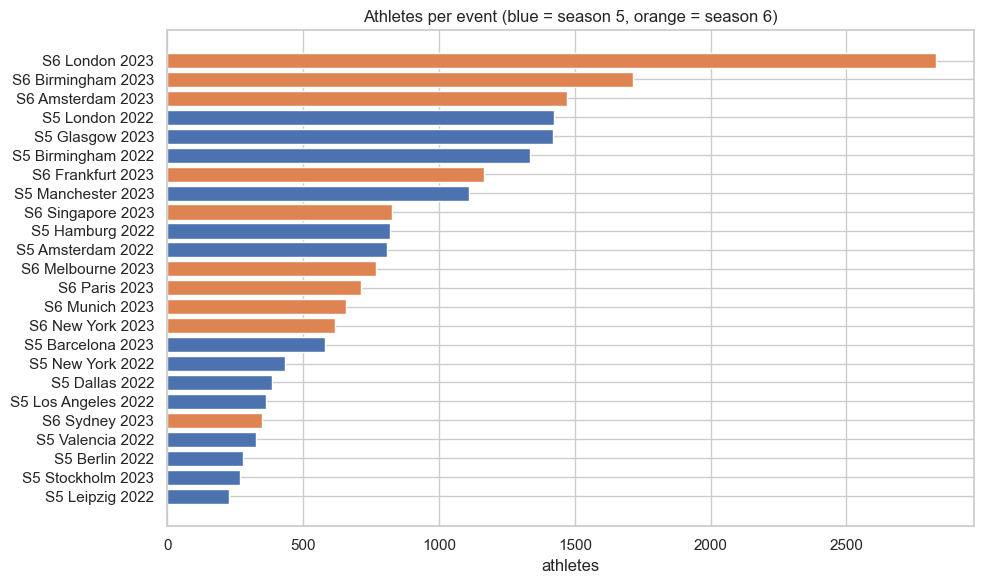

In [2]:
events = (raw.groupby(["season", "event_name", "location"]).size()
          .rename("athletes").reset_index())
print(f"{events.event_name.nunique()} events, {events.location.nunique()} venues, "
      f"seasons {sorted(raw.season.unique())}")

fig, ax = plt.subplots(figsize=(10, 6))
order = events.sort_values("athletes")
colors = order["season"].map({5: "#4C72B0", 6: "#DD8452"})
ax.barh(order["event_name"], order["athletes"], color=colors)
ax.set_xlabel("athletes")
ax.set_title("Athletes per event (blue = season 5, orange = season 6)")
plt.tight_layout()

## Data Cleaning

Before modeling, the raw scrape was audited against five questions: gender composition,
missing/zero splits, DNF policy, duplicates, and venue coverage. Each finding below becomes an
explicit, counted cleaning rule.

### Duplicates

Two different mechanisms, needing different responses:

- **Exact duplicate rows.** The results site renders duplicate `<li>` rows for some athletes
  (responsive desktop/mobile layouts) and the scraper followed both — render artifacts, dropped.
- **Repeated bib numbers** within an event belong to *different people* (bibs are reused across
  start waves), so `bib_number` cannot be used as a key. Same-name pairs within one event are
  also real distinct athletes — names aren't identifiers either.

In [3]:
print(f"exact duplicate rows:     {raw.duplicated().sum():>6,}  <- site render artifacts, dropped")
print(f"(event, bib) duplicates:  {raw.duplicated(['event_id','bib_number']).sum():>6,}  <- bib reuse, different people, kept")
print(f"(event, name) duplicates: {raw.duplicated(['event_id','name']).sum():>6,}  <- mostly render artifacts; same-name collisions kept")
dd = raw.drop_duplicates()
print(f"\nafter exact-duplicate drop: {len(dd):,} rows")

exact duplicate rows:        455  <- site render artifacts, dropped
(event, bib) duplicates:   1,357  <- bib reuse, different people, kept
(event, name) duplicates:    507  <- mostly render artifacts; same-name collisions kept

after exact-duplicate drop: 20,432 rows


### Zero splits encode missing data

The splits contain no NaNs — zeros are the missing-data encoding (a missed checkpoint mat, not a
zero-second segment). They concentrate in the late runs, consistent with mat misses accumulating
late in the race rather than random data-entry noise. These become NaN, with a per-row
`n_missing_splits` counter.

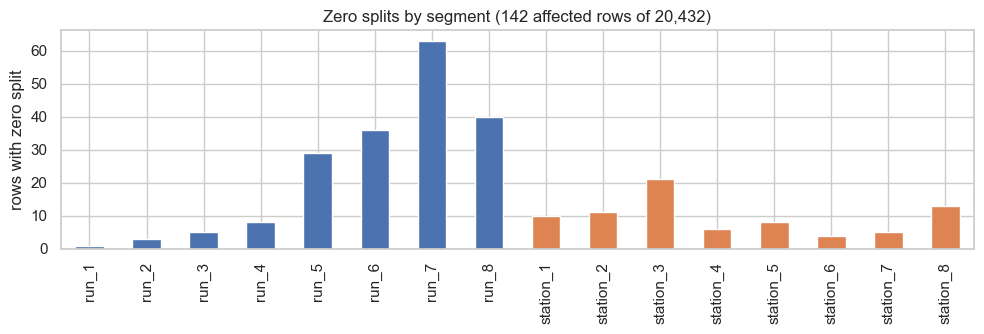

In [4]:
zero_by_col = (dd[SPLIT_COLS] == 0).sum()
fig, ax = plt.subplots(figsize=(10, 3.5))
zero_by_col.plot.bar(ax=ax, color=["#4C72B0"] * 8 + ["#DD8452"] * 8)
ax.set_ylabel("rows with zero split")
ax.set_title(f"Zero splits by segment ({(dd[SPLIT_COLS] == 0).any(axis=1).sum()} affected rows of {len(dd):,})")
plt.tight_layout()

### The Paris anomaly

For a clean row, `sum(16 splits) + roxzone` should reconcile with the official overall time to
within a few seconds of rounding. One event breaks this completely: **S6 Paris published no
roxzone times at all**. Its splits under-account the overall time by exactly one roxzone-sized
gap — the implied value sits right on the global roxzone distribution — so roxzone is imputed as
`overall − Σsplits` wherever it is missing and the splits are complete.

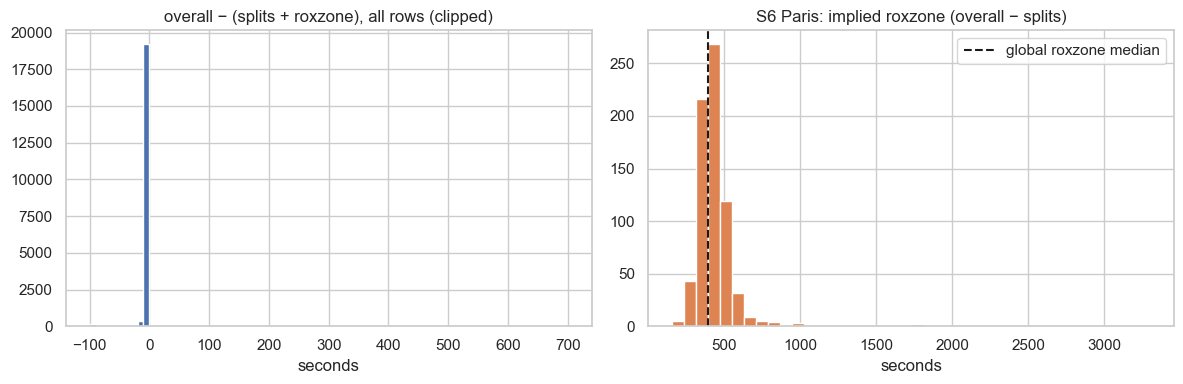

In [5]:
recon = dd[SPLIT_COLS].sum(axis=1) + dd["roxzone_time"]
gap = dd["overall_time"] - recon

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gap.clip(-100, 700).hist(bins=80, ax=axes[0])
axes[0].set_title("overall − (splits + roxzone), all rows (clipped)")
axes[0].set_xlabel("seconds")

paris = dd[dd.event_name == "S6 Paris 2023"]
(paris["overall_time"] - paris[SPLIT_COLS].sum(axis=1)).hist(bins=40, ax=axes[1], color="#DD8452")
axes[1].axvline(dd.loc[dd.roxzone_time > 0, "roxzone_time"].median(), color="k", ls="--",
                label="global roxzone median")
axes[1].set_title("S6 Paris: implied roxzone (overall − splits)")
axes[1].set_xlabel("seconds")
axes[1].legend()
plt.tight_layout()

### DNF policy

`disqual_reason` is empty and every row carries a positive finish time: the source lists
**finishers only**. Nothing to clean, but it sets a standing caveat — every model in this project
estimates outcomes *conditional on finishing*, and no survivorship correction is possible from
this data.

### The cleaning policy, as code

Each audit finding is implemented as an explicit, counted rule in
[`src/processing/cleaning.py`](../src/processing/cleaning.py), and the audit trail prints with
every build:

| rule | action | rationale |
|------|--------|-----------|
| R1 | drop exact duplicate rows | site render artifacts |
| R2 | recompute derived totals; impute missing roxzone | unpublished fields (Paris) |
| R3 | zero splits → NaN + `n_missing_splits` | zeros encode missing mats |
| R4 | `splits_consistent` flag (±60s reconciliation) | catch corrupt rows |
| R5 | join gender/age/nationality labels | recovered via list-page scrape |
| R6 | drop dead (all-empty) columns | silent parse failures |

Rows are **flagged, not dropped** (`is_modeling_row`), so each downstream analysis chooses its
own strictness. One honest caveat: rows with imputed roxzone reconcile in R4 by construction, so
the consistency check only bites on rows that arrived with a published roxzone.

In [6]:
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)
from src.processing.cleaning import clean_raw_dataset

clean = clean_raw_dataset(raw, labels=labels)
n_model = clean["is_modeling_row"].sum()
print(f"\nretention: {n_model:,} modeling rows / {len(raw):,} scraped ({n_model/len(raw):.1%})")

R1: dropped 455 exact duplicate rows (20887 -> 20432)


R2: imputed roxzone_time for 699 rows (was 0, splits complete)


R2: recomputed total_run / total_stations / best_run_lap from splits


R3: 142 rows had >=1 zero split -> NaN (n_missing_splits set)


R4: 229 rows fail consistency (|overall - splits - rox| > 60s)


R5: gender labels — 20429 exact, 0 fallback, 3 unmatched (99.99% labeled)


R6: dropped dead columns: ['division', 'age_group', 'nationality', 'disqual_reason', 'bonus_time', 'penalty_time']


Final: 20203 / 20432 rows flagged is_modeling_row



retention: 20,203 modeling rows / 20,887 scraped (96.7%)


## Exploratory Data Analysis

### Gender, recovered

The label join attaches gender to 99.99% of rows (3 unmatched). The field is roughly **69% men,
31% women**, and the two finish-time distributions are visibly offset — an unlabeled mixture
would have inflated the variance of every model downstream.

gender
M      14109
W       6320
NaN        3


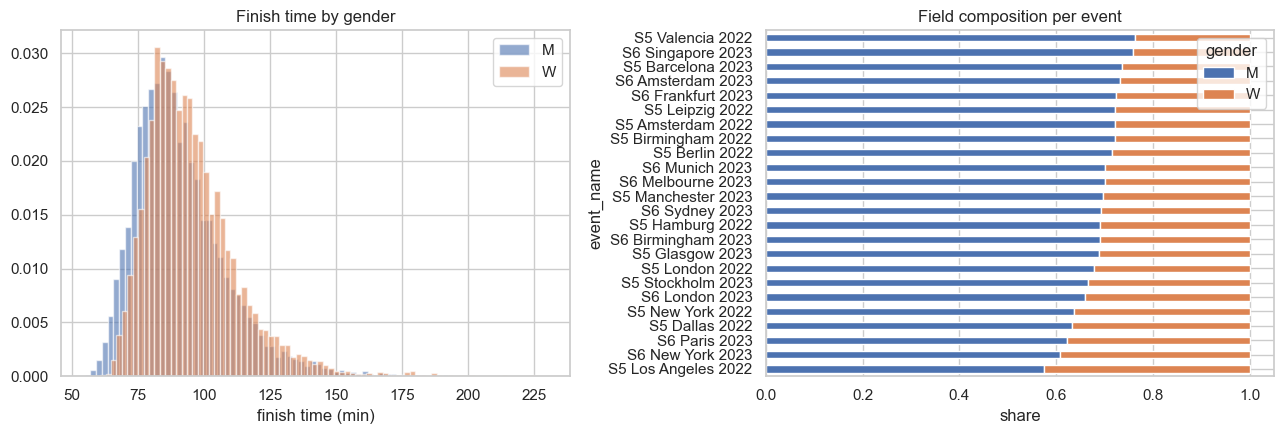

In [7]:
print(clean["gender"].value_counts(dropna=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for g, color in [("M", "#4C72B0"), ("W", "#DD8452")]:
    (clean.loc[clean.gender == g, "overall_time"] / 60).hist(
        bins=80, alpha=0.6, label=g, ax=axes[0], color=color, density=True)
axes[0].set_xlabel("finish time (min)")
axes[0].set_title("Finish time by gender")
axes[0].legend()

mix = (clean.groupby("event_name")["gender"]
       .value_counts(normalize=True).unstack().fillna(0))
mix.sort_values("M").plot.barh(stacked=True, ax=axes[1],
                               color={"M": "#4C72B0", "W": "#DD8452"}, legend=True)
axes[1].set_title("Field composition per event")
axes[1].set_xlabel("share")
plt.tight_layout()

### Anatomy of a race

Median time by segment shows the race's structure: runs slow steadily after a fast first
kilometre, and the heavy stations (sled push/pull early, lunges and wall balls late) are where
the variance lives. The widening gap between the genders on strength stations (sleds, carry) vs
runs is exactly the kind of structure the pacing-archetype analysis will pick at.

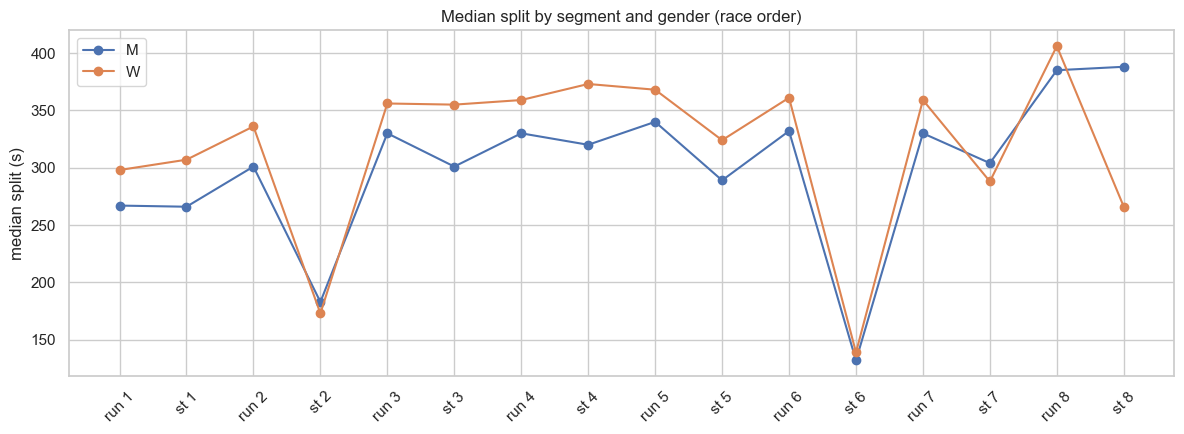

In [8]:
model_rows = clean[clean.is_modeling_row]
seg_order = [c for pair in zip(RUN_COLS, STATION_COLS) for c in pair]
seg_labels = [c.replace("station_", "st ").replace("run_", "run ") for c in seg_order]

fig, ax = plt.subplots(figsize=(12, 4.5))
for g, color in [("M", "#4C72B0"), ("W", "#DD8452")]:
    med = model_rows.loc[model_rows.gender == g, seg_order].median()
    ax.plot(range(16), med.values, "o-", color=color, label=g)
ax.set_xticks(range(16), seg_labels, rotation=45)
ax.set_ylabel("median split (s)")
ax.set_title("Median split by segment and gender (race order)")
ax.legend()
plt.tight_layout()

### Venue differences — the raw signal for the hierarchical model

Venue coverage is adequate for random effects: **20 venues / 24 events**, 226–2,828 athletes per
event, and 4 venues repeat across seasons (which helps separate venue effects from
event-edition effects). Raw event medians span ~24 minutes (Barcelona → Singapore) — but this
spread is **confounded**: it mixes true course difficulty with who shows up. Gender mix alone
explains little of it (r ≈ −0.19), so the confounder is field strength broadly. Disentangling
that is Phase 3's identification problem.

event median vs %men: r = -0.19


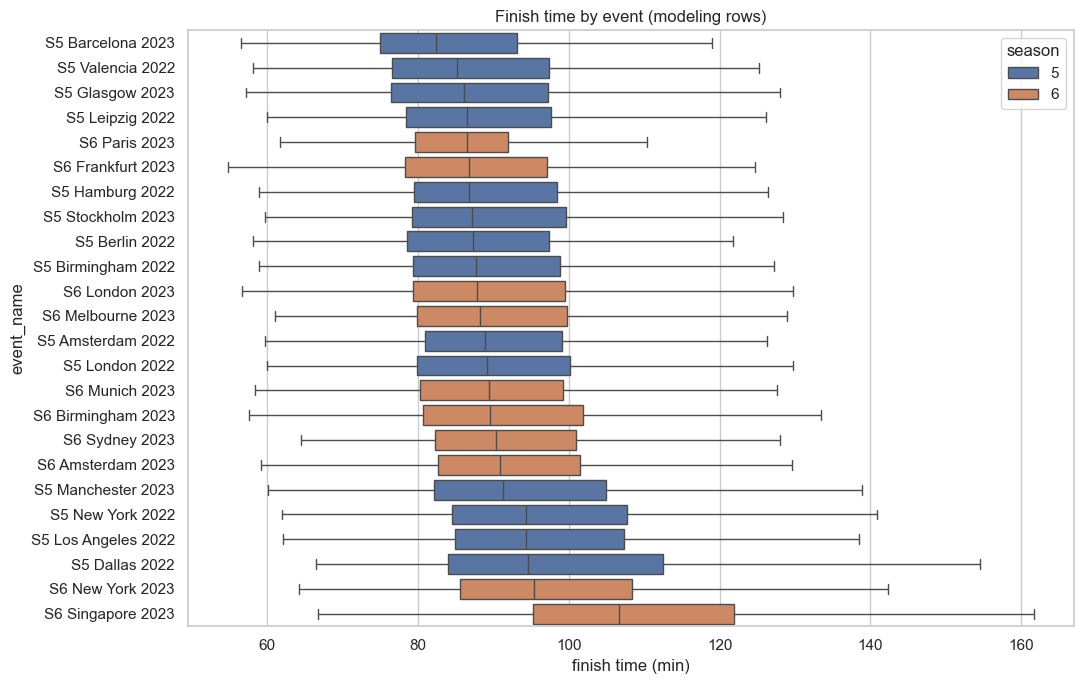

In [9]:
venue_order = (model_rows.groupby("event_name")["overall_time"].median()
               .sort_values().index)

fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(data=model_rows.assign(minutes=model_rows.overall_time / 60),
            y="event_name", x="minutes", order=venue_order,
            hue="season", palette={5: "#4C72B0", 6: "#DD8452"},
            showfliers=False, ax=ax)
ax.set_title("Finish time by event (modeling rows)")
ax.set_xlabel("finish time (min)")
plt.tight_layout()

ev = (model_rows.groupby("event_name")
      .agg(median_min=("overall_time", lambda s: s.median() / 60),
           pct_men=("gender", lambda s: (s == "M").mean())))
print(f"event median vs %men: r = {ev['median_min'].corr(ev['pct_men']):.2f}")

### Repeat athletes

Exact name matching across events finds a meaningful pool of repeat competitors — a possible
identification aid for the venue model (within-athlete contrasts), though with the caveat that
names are not reliable IDs.

In [10]:
ne = clean.drop_duplicates(["event_id", "name"]).groupby("name")["event_id"].nunique()
print(f"names appearing in 2+ events: {(ne > 1).sum():,} | 3+ events: {(ne > 2).sum():,}")

names appearing in 2+ events: 2,115 | 3+ events: 389


## Summary & Next Steps

| audit question | answer |
|---|---|
| gender composition | not captured by the scrape; **recovered for 99.99% of rows** via a list-page label pass (69% M / 31% W) |
| missing/zero splits | zeros = missed mats; ~0.7% of rows, late-run concentrated → NaN + flag |
| DNF policy | finishers only → all models conditional on finishing |
| duplicates | 455 render artifacts dropped; bibs and names are not identifiers |
| venue adequacy | 20 venues / 24 events with n ≥ 226 → adequate for venue random effects |

The clean modeling table (`data/processed/hyrox_clean.csv`) retains **96.7%** of scraped rows
under the strict filter, with all cleaning decisions implemented as counted, reproducible rules.

**Notebook 2** builds the flagship in-race prediction models: per-checkpoint feature sets using
only information available at each checkpoint, a domain-naive proportional-extrapolation
baseline, leave-event-out cross-validation, and calibrated prediction intervals.